In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys

path = '/content/drive/MyDrive/projekt_interdyscyplinarny/models'
os.chdir(path)
sys.path.append(path)

print(os.listdir())

['combine_features.py', 'mateusz-model.ipynb', 'mateusz-ca-model.ipynb', 'mateusz-eda.ipynb', 'mateusz-fe.ipynb', 'olek-fe.ipynb', 'olek-model.ipynb', '__pycache__', '.ipynb_checkpoints', 'krzysiek_model.ipynb']


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import json

from catboost import CatBoostRegressor
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import mean_squared_error

from combine_features import read_data

In [ ]:
dict = pd.read_csv('../rhea-soil-nutrient-prediction-challenge/data_dictionary.csv')

for i in range(0, 25):
    print(dict['column_name'][i] + ' - ' + dict['description'][i])
    print()

ID - Unique identifier for the soil sampling location or observation.

Longitude - Longitude coordinate of the sampling location in decimal degrees.

Latitude - Latitude coordinate of the sampling location in decimal degrees.

start_date - Start date of the period during which the soil observation or aggregation is valid.

end_date - End date of the period during which the soil observation or aggregation is valid.

horizon_lower - Lower depth boundary of the soil horizon in centimetres.

horizon_upper - Upper depth boundary of the soil horizon in centimetres.

Depth_cm - Textual representation of the soil depth interval (e.g. '20–50 cm').

Al - Extractable aluminium concentration in the soil (mg/kg or 1ppm).

B - Extractable boron concentration in the soil (mg/kg or 1ppm).

Ca - Extractable calcium concentration in the soil (mg/kg or 1ppm).

C_organic - Organic carbon by combustion after acidification (mg/kg or 1ppm).

C_total - Total carbon by combustion (mg/kg or 1ppm).

Cu - Extract

In [ ]:
df = read_data("../rhea-soil-nutrient-prediction-challenge/Train.csv")
df.columns.values

array(['ID', 'Longitude', 'Latitude', 'Depth_cm', 'ph_x', 'Area',
       'tmin_avg', 'tmax_avg', 'prec_avg', 'B11_x', 'B12_x', 'B2', 'B3',
       'B4', 'B8', 'aspect', 'elevation', 'hillshade', 'slope',
       'cec_0-5cm_mean', 'cec_15-30cm_mean', 'cec_30-60cm_mean',
       'cec_5-15cm_mean', 'clay_0-5cm_mean', 'clay_15-30cm_mean',
       'clay_30-60cm_mean', 'clay_5-15cm_mean', 'phh2o_0-5cm_mean',
       'phh2o_15-30cm_mean', 'phh2o_30-60cm_mean', 'phh2o_5-15cm_mean',
       'sand_0-5cm_mean', 'sand_15-30cm_mean', 'sand_30-60cm_mean',
       'sand_5-15cm_mean', 'soc_0-5cm_mean', 'soc_15-30cm_mean',
       'soc_30-60cm_mean', 'soc_5-15cm_mean', 'B04', 'B05', 'B06', 'B07',
       'B08', 'B09', 'B10', 'B11_y', 'B12_y', 'B13', 'B14', 'Al_pred',
       'Ca_pred', 'Fe_pred', 'K_pred', 'Mg_pred', 'N_pred', 'P_pred',
       'S_pred', 'Zn_pred', 'carbon', 'clay', 'ph_y', 'Bananas',
       'Beans, dry', 'Cashew nuts, in shell', 'Cassava, fresh',
       'Chillies and peppers, green (Capsicum spp

## Preprocessing

In [16]:
# Data
train_df = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/Train.csv")
train_df.drop(columns='ph', inplace=True)
test_df = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/TestSet.csv")
pred_to_keep = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/TargetPred_To_Keep.csv")

# Features
landforms_df = pd.read_csv('../features/OpenLandMap_features.csv')
landforms_df.drop(columns = 'Unnamed: 0', inplace=True)

cire_df = pd.read_csv('../features/CIre-feature.csv')
cire_df.drop(columns='Unnamed: 0', inplace=True)

olek_features = pd.read_csv("../features/olek-features.csv")
olek_features.drop(columns=['B11_x', 'B12_x', 'B2', 'B3', 'B4', 'B8'], inplace=True, errors='ignore')
features = olek_features.copy()
features.drop(columns=['Country', 'Area'], inplace=True)
# New
features['ratio_Ca_Mg'] = features['Ca_pred'] / (features['Mg_pred'] + 0.001)
features['ratio_Fe_Al'] = features['Fe_pred'] / (features['Al_pred'] + 0.001)
features['CIA_proxy'] = features['Al_pred'] / (features['Al_pred'] + features['Ca_pred'] 
                                               + features['K_pred'] + 0.001)
def calc_soil_features(data):
    df = data.copy()
    
    # Różnica pasm SWIR (B11-B12) - kluczowa dla minerałów ilastych (gliny)
    df['diff_swir'] = df['B11_y'] - df['B12_y']
    # Różnica Red-NIR - podstawa do oceny tekstury gleby
    df['diff_red_nir'] = df['B04'] - df['B08']

    # Clay Index (Wskaźnik Gliny) - standard w geologii
    df['clay_index'] = df['B11_y'] / (df['B12_y'] + 1e-6)

    # Indeks Tlenków Żelaza (Proxy)
    df['iron_oxide_proxy'] = df['B04'] / (df['B11_y'] + 1e-6)

    # Nachylenie Red Edge (Slope) świetnie wyłapuje różnice w typach gleb.
    df['red_edge_slope'] = (df['B07'] - df['B05']) / (df['B07'] + df['B05'] + 1e-6)
    df['red_edge_peak'] = df[['B05', 'B06', 'B07']].mean(axis=1)

    # NDVI = (B08 - B04) / (B08 + B04)
    df['ndvi'] = (df['B08'] - df['B04']) / (df['B08'] + df['B04'] + 1e-6)

    return df

features = calc_soil_features(features)

features = features.merge(landforms_df, on='ID', how = 'left')
features = features.merge(cire_df, on='ID', how = 'left')

train = pd.merge(train_df, features, on='ID', how='left')
test = pd.merge(test_df, features, on='ID', how='left')


In [18]:
encoder = LabelEncoder()
train['Depth'] = encoder.fit_transform(train['Depth_cm'])
test['Depth'] = encoder.transform(test['Depth_cm'])
train.drop(columns=['ID', 'Area', 'Depth_cm'], inplace=True, errors='ignore')
test.drop(columns=['ID', 'Depth_cm'], inplace=True, errors='ignore')

train["Na"] = train["Na"].fillna(train["Na"].mean(), inplace=False)
train = train.fillna(0, inplace=False)

C:\Users\acer\AppData\Local\Temp\ipykernel_14264\3408710149.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['Depth'] = encoder.fit_transform(train['Depth_cm'])
C:\Users\acer\AppData\Local\Temp\ipykernel_14264\3408710149.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['Depth'] = encoder.transform(test['Depth_cm'])


In [19]:
# Definicja pierwiastków do przewidzenia
target = ['Al', 'B', 'Ca', "C_organic", "C_total", 'Cu', 'Fe', 'K', 'Mg', 'Mn', 'N', 'Na', 'P', 'S', 'Zn']

X = train.drop(columns=target, errors='ignore')
y_columns = train.columns.difference(X.columns)
y_columns = [col for col in y_columns if col not in ["C_organic", "C_total", "Area", "Depth_cm", "ID"]]
y = train[y_columns]

In [20]:
y.columns

Index(['Al', 'B', 'Ca', 'Cu', 'Fe', 'K', 'Mg', 'Mn', 'N', 'Na', 'P', 'S',
       'Zn'],
      dtype='str')

In [21]:
target_pred = [
    "Target_Al",
    "Target_B",
    "Target_Ca",
    "Target_Cu",
    "Target_Fe",
    "Target_K",
    "Target_Mg",
    "Target_Mn",
    "Target_N",
    "Target_Na",
    "Target_P",
    "Target_S",
    "Target_Zn",
]

X_pred = test.drop(columns=target_pred, errors='ignore')
y_pred_columns = test.columns.difference(X_pred.columns)
y_pred_columns = [col for col in y_pred_columns if col not in ["C_organic", "C_total", "Area", "Depth_cm", "ID"]]
y_pred = test[y_pred_columns]

In [22]:
y_pred.columns

Index(['Target_Al', 'Target_B', 'Target_Ca', 'Target_Cu', 'Target_Fe',
       'Target_K', 'Target_Mg', 'Target_Mn', 'Target_N', 'Target_Na',
       'Target_P', 'Target_S', 'Target_Zn'],
      dtype='str')

In [23]:
diff = set(X.columns) - set(X_pred.columns)
print(diff)
X.drop(columns=diff, inplace=True)

ph = X['ph']
X = X.drop(columns=['ph'], errors='ignore')

X_pred = X_pred[X.columns]

{'electrical_conductivity', 'horizon_upper', 'horizon_lower', 'start_date', 'end_date'}


In [24]:
groups = X['Longitude'].astype(str) + "_" + X['Latitude'].astype(str)

print(f"Unikalne lokalizacje: {groups.nunique()}")
print(f"Wszystkie próbki: {len(groups)}")

Unikalne lokalizacje: 34823
Wszystkie próbki: 44298


In [ ]:
# scaler = StandardScaler()
# numeric_cols = X.select_dtypes(include=[np.number]).columns
# X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
# X_pred[numeric_cols] = scaler.transform(X_pred[numeric_cols])

In [25]:
features_to_drop = ['Longitude', 'Latitude', 'Depth']

X.drop(columns=features_to_drop, inplace=True, errors='ignore')
X_pred.drop(columns=features_to_drop, inplace=True, errors='ignore')

In [26]:
X.columns

Index(['tmin_avg', 'tmax_avg', 'prec_avg', 'aspect', 'elevation', 'hillshade',
       'slope', 'cec_0-5cm_mean', 'cec_15-30cm_mean', 'cec_30-60cm_mean',
       ...
       'soil_397', 'soil_398', 'soil_400', 'soil_402', 'soil_413', 'soil_419',
       'soil_420', 'soil_429', 'soil_430', 'CIre'],
      dtype='str', length=150)

In [27]:
# Logarytmowanie (do treningu)
y_log = np.log1p(y[y.columns])

## CatBoost tuning with Optuna

In [111]:
def objective(trial, X, y, groups):
    params = {
        "iterations": 500,
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-1, 10.0),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": 'MultiRMSE', # Wiele targetów naraz
        "verbose": False,
        "allow_writing_files": False,
        "task_type": "GPU",
        "boosting_type": "Plain"
    }

    # Walidacja krzyżowa
    gkf = GroupKFold(n_splits=3)
    rmse_scores = []

    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_t, y_t, eval_set=(X_v, y_v), early_stopping_rounds=50, verbose=False)

        preds = model.predict(X_v)
        rmse = np.sqrt(mean_squared_error(y_v, preds))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [17]:
# Uruchomienie tuningu
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X, y_log, groups), n_trials=12)

[I 2026-03-07 18:50:15,435] A new study created in memory with name: no-name-ab127ec1-fca5-49f5-8fcc-565e7eb19a31
[I 2026-03-07 18:54:24,570] Trial 0 finished with value: 0.3434865977175712 and parameters: {'depth': 7, 'learning_rate': 0.007062829398506994, 'l2_leaf_reg': 9.104321444997975, 'random_strength': 3.3243658304610544, 'bagging_temperature': 0.3191902181737173, 'border_count': 172}. Best is trial 0 with value: 0.3434865977175712.
[I 2026-03-07 18:57:40,327] Trial 1 finished with value: 0.33383250283676386 and parameters: {'depth': 6, 'learning_rate': 0.009249157589815274, 'l2_leaf_reg': 2.081945006549438, 'random_strength': 4.335586915638754, 'bagging_temperature': 0.005576401455737345, 'border_count': 226}. Best is trial 1 with value: 0.33383250283676386.
[I 2026-03-07 19:00:51,132] Trial 2 finished with value: 0.4733775828959464 and parameters: {'depth': 6, 'learning_rate': 0.001744081572382257, 'l2_leaf_reg': 7.132947254970933, 'random_strength': 6.916392029770699, 'baggin

In [77]:
# 1. Pobranie najlepszych parametrów
best_params = study.best_params
print("Najlepsze parametry:", best_params)

# 2. Dodanie parametrów stałych, których Optuna nie tuningowała
final_params = {
    **best_params,
    "iterations": 2000,
    "loss_function": 'MultiRMSE',
    "verbose": 100,
    "task_type": "GPU",
    "devices": "0",
    "boosting_type": "Plain"
}

Najlepsze parametry: {'depth': 8, 'learning_rate': 0.2399282861340109, 'l2_leaf_reg': 9.984725901873947, 'random_strength': 6.484683905283281, 'bagging_temperature': 0.990981110155492, 'border_count': 128}


In [22]:
import joblib

# Zapis całego badania (wszystkie próby, nie tylko najlepsza)
joblib.dump(study, 'optuna_study_soil.pkl')

# Wczytanie i kontynuacja:
# study = joblib.load('optuna_study_soil.pkl')
# study.optimize(objective, n_trials=10)

best_params = study.best_params

# Zapisywanie do pliku na Dysku Google
with open('catboost_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)

print("Parametry zapisane!")

# Jak je wczytać później:
# with open('catboost_best_params.json', 'r') as f:
#     loaded_params = json.load(f)

Parametry zapisane!


In [ ]:
study2 = optuna.create_study(direction="minimize")
study2.optimize(lambda trial: objective(trial, X, y_log, groups), n_trials=20)
joblib.dump(study2, 'optuna_study_soil2.pkl')

[I 2026-03-07 23:25:24,358] A new study created in memory with name: no-name-2df4f049-4ca8-47e1-a82e-e0f30fe69227
[I 2026-03-07 23:26:10,038] Trial 0 finished with value: 0.26530445824199994 and parameters: {'depth': 8, 'learning_rate': 0.008999736778028898, 'l2_leaf_reg': 8.515398850471914, 'random_strength': 7.536411603800984, 'bagging_temperature': 0.18895173666418796, 'border_count': 216}. Best is trial 0 with value: 0.26530445824199994.
[I 2026-03-07 23:26:22,471] Trial 1 finished with value: 0.2482023140820406 and parameters: {'depth': 4, 'learning_rate': 0.06938203348807762, 'l2_leaf_reg': 4.843761538594644, 'random_strength': 9.021860620652305, 'bagging_temperature': 0.7965319810483896, 'border_count': 204}. Best is trial 1 with value: 0.2482023140820406.
[I 2026-03-07 23:27:02,222] Trial 2 finished with value: 0.3231989568073162 and parameters: {'depth': 8, 'learning_rate': 0.0028396931242228043, 'l2_leaf_reg': 8.457442142707826, 'random_strength': 4.40520568927997, 'bagging_t

In [ ]:
best_params2 = study2.best_params
with open('catboost_best_params2.json', 'w') as f:
    json.dump(best_params2, f, indent=4)
print("Najlepsze parametry:", best_params2)

final_params = {
    **best_params,
    "iterations": 2000,
    "loss_function": 'MultiRMSE',
    "verbose": 100,
    "task_type": "CPU",
    "devices": "0",
    "boosting_type": "Plain"
}

## CatBoost training and final prediction

In [30]:
with open('catboost_best_params.json', 'r') as f: 
    loaded_params = json.load(f)

final_params = {
    **loaded_params,
    "iterations": 2000,
    "loss_function": 'MultiRMSE',
    "verbose": 100,
    "task_type": "CPU"
}

In [31]:
# 3. Trenowanie ostatecznego modelu na CAŁYM zbiorze danych
final_model = CatBoostRegressor(**final_params)
final_model.fit(X, y_log)


0:	learn: 1.7192959	total: 547ms	remaining: 18m 13s
100:	learn: 0.8359250	total: 46.4s	remaining: 14m 31s
200:	learn: 0.7817627	total: 2m	remaining: 17m 54s
300:	learn: 0.7516142	total: 3m 15s	remaining: 18m 26s
400:	learn: 0.7244367	total: 4m 26s	remaining: 17m 41s
500:	learn: 0.6993313	total: 5m 45s	remaining: 17m 13s
600:	learn: 0.6766843	total: 6m 59s	remaining: 16m 15s
700:	learn: 0.6568115	total: 8m 30s	remaining: 15m 45s
800:	learn: 0.6381691	total: 9m 59s	remaining: 14m 56s
900:	learn: 0.6208699	total: 11m 15s	remaining: 13m 43s
1000:	learn: 0.6063832	total: 13m 4s	remaining: 13m 3s
1100:	learn: 0.5921934	total: 14m 32s	remaining: 11m 52s
1200:	learn: 0.5805899	total: 16m 34s	remaining: 11m 1s
1300:	learn: 0.5692995	total: 17m 52s	remaining: 9m 36s
1400:	learn: 0.5573897	total: 18m 57s	remaining: 8m 6s
1500:	learn: 0.5448026	total: 20m 1s	remaining: 6m 39s
1600:	learn: 0.5353350	total: 21m 8s	remaining: 5m 16s
1700:	learn: 0.5269678	total: 22m 34s	remaining: 3m 58s
1800:	learn:

CatBoostRegressor(bagging_temperature=0.990981110155492, border_count=128, depth=8, iterations=2000, l2_leaf_reg=9.984725901873947, learning_rate=0.2399282861340109, loss_function='MultiRMSE', random_strength=6.484683905283281, task_type='CPU', verbose=100)

In [32]:
# 4. Zapisanie modelu na później
final_model.save_model("catboost_soil_model3.cbm")

In [33]:
def plot_feature_importance(model, feature_names, top_n=20):
    # 1. Pobranie ważności cech
    fi = model.get_feature_importance()

    # 2. Stworzenie ramki danych dla łatwiejszego sortowania
    fi_df = pd.DataFrame({
        'feature': feature_names,
        'importance': fi
    }).sort_values(by='importance', ascending=False)

    # 3. Wykres
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='importance',
        y='feature',
        data=fi_df.head(top_n),
        palette='viridis'
    )

    plt.title(f'Top {top_n} Najważniejszych Cech - CatBoost', fontsize=15)
    plt.xlabel('Wartość ważności (Importance)', fontsize=12)
    plt.ylabel('Cecha', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_14264\1254958634.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


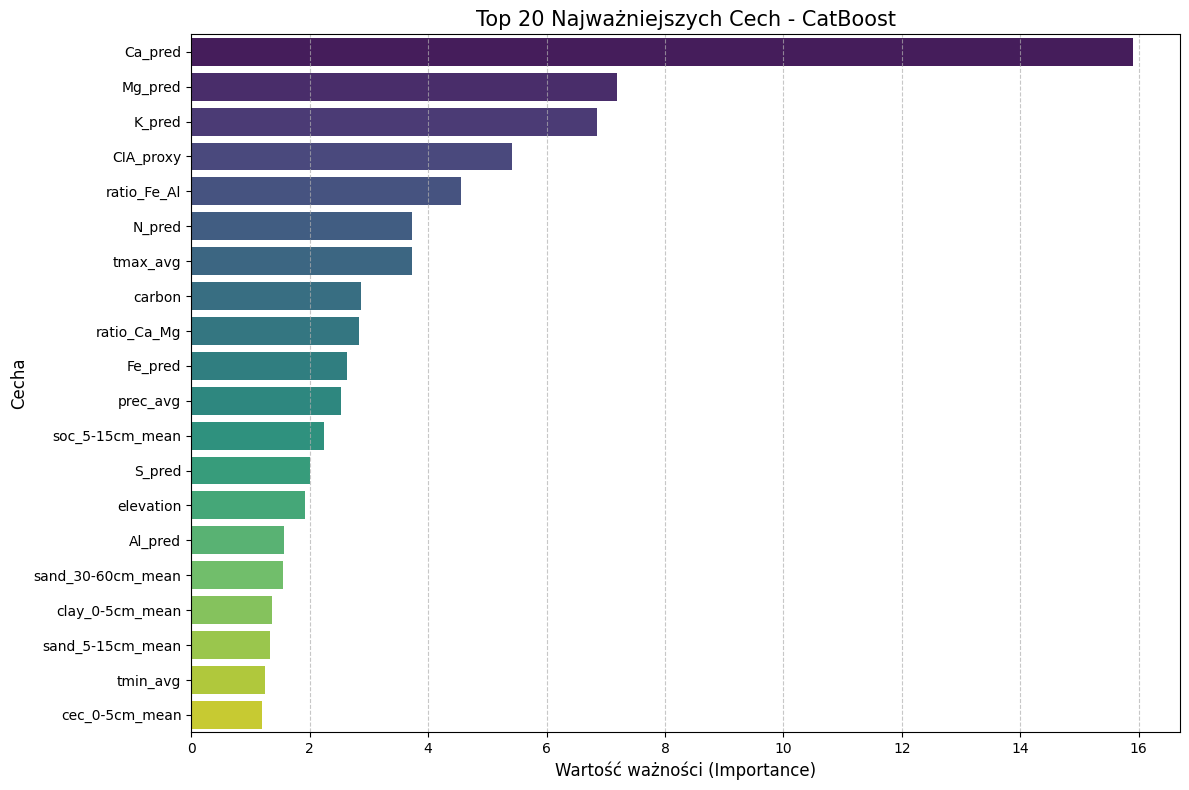

In [34]:
feature_importance = final_model.get_feature_importance(type='FeatureImportance')
plot_feature_importance(final_model, X.columns, top_n=20)

In [35]:
# 5. Predykcje na zbiorze testowym
test_preds_log = final_model.predict(X_pred)
test_preds = np.expm1(test_preds_log)

In [36]:
id = test_df["ID"]
test_pred_df = pd.DataFrame(test_preds, columns=target_pred)
result = pd.concat([id, test_pred_df], axis=1)
result.head()

,ID,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,Target_N,Target_Na,Target_P,Target_S,Target_Zn
0,8ZMJRO,1225.811503,0.001175,1557.584993,4.033820,111.273132,536.969439,464.143513,120.562074,2.560910,38.481795,0.018018,0.039200,0.010878
1,DCC6DM,899.958865,0.002612,955.527210,2.358013,140.406297,248.326186,303.486162,98.430774,1.619189,37.714997,0.077354,0.018668,0.009229
2,T50LK1,1085.235613,0.000844,908.345883,3.033045,140.503187,167.922997,244.855553,109.490205,1.483106,37.588908,0.075958,0.055650,0.018481
3,FNLYT0,726.985461,0.007982,1646.558462,2.017939,153.452002,516.417872,313.299484,99.968581,2.646604,37.902884,0.125181,0.090082,0.038603
4,FP5E12,603.787604,-0.000523,1517.749893,1.876556,116.206041,344.893076,322.243815,88.026296,1.022326,38.154457,-0.072105,-0.062702,-0.031171


In [37]:
def evaluate_predictions(y_true, y_pred_df):
    """
    y_true: Ramka z prawdziwymi wartościami (np. y_test lub y_pred)
    y_pred_df: Ramka z Twoimi predykcjami (już po np.expm1)
    """
    
    cols = y_true.columns
    y_pred_ordered = y_pred_df[cols]

    rmse_per_nutrient = {}

    print(f"{'Pierwiastek':<12} | {'RMSE':<10}")
    print("-" * 25)
    
    for col in cols:
        rmse = np.sqrt(mean_squared_error(y_true[col], y_pred_ordered[col]))
        rmse_per_nutrient[col] = rmse
        print(f"{col:<12} | {rmse:<10.4f}")

    mean_rmse = np.mean(list(rmse_per_nutrient.values()))
    print("-" * 25)
    print(f"{'ŚREDNIE RMSE':<12} | {mean_rmse:<10.4f}")

    return rmse_per_nutrient


In [38]:
results = evaluate_predictions(y_pred, test_pred_df)

Pierwiastek  | RMSE      
-------------------------
Target_Al    | 855.4542  
Target_B     | 0.0142    
Target_Ca    | 2822.2430 
Target_Cu    | 2.5860    
Target_Fe    | 116.3303  
Target_K     | 323.2876  
Target_Mg    | 458.7202  
Target_Mn    | 128.0156  
Target_N     | 1.3288    
Target_Na    | 37.9322   
Target_P     | 1.1504    
Target_S     | 1.4417    
Target_Zn    | 0.2203    
-------------------------
ŚREDNIE RMSE | 365.2865  


In [44]:
with open('catboost_best_params2.json', 'r') as f: 
    loaded_params2 = json.load(f)

final_params2 = {
    **loaded_params2,
    "iterations": 2000,
    "loss_function": 'MultiRMSE',
    "verbose": 100,
    "task_type": "CPU"
}

final_model2 = CatBoostRegressor(**final_params2)
final_model2.fit(X, y_log)

final_model2.save_model("catboost_soil_model4.cbm")

test_preds_log2 = final_model2.predict(X_pred)
test_preds2 = np.expm1(test_preds_log2)

id = test_df["ID"]
test_pred_df2 = pd.DataFrame(test_preds2, columns=target_pred)
result = pd.concat([id, test_pred_df2], axis=1)
result.head()

0:	learn: 1.8574671	total: 427ms	remaining: 14m 14s
100:	learn: 0.9258372	total: 43.9s	remaining: 13m 44s
200:	learn: 0.8367367	total: 2m 9s	remaining: 19m 17s
300:	learn: 0.7746285	total: 4m 3s	remaining: 22m 56s
400:	learn: 0.7371454	total: 5m 19s	remaining: 21m 14s
500:	learn: 0.7067772	total: 6m 44s	remaining: 20m 10s
600:	learn: 0.6833001	total: 8m 34s	remaining: 19m 56s
700:	learn: 0.6615267	total: 10m 31s	remaining: 19m 30s
800:	learn: 0.6424364	total: 12m 22s	remaining: 18m 31s
900:	learn: 0.6256405	total: 13m 48s	remaining: 16m 50s
1000:	learn: 0.6096980	total: 15m 17s	remaining: 15m 15s
1100:	learn: 0.5949616	total: 16m 57s	remaining: 13m 50s
1200:	learn: 0.5813818	total: 18m 41s	remaining: 12m 26s
1300:	learn: 0.5677912	total: 20m 11s	remaining: 10m 50s
1400:	learn: 0.5551678	total: 21m 10s	remaining: 9m 3s
1500:	learn: 0.5430412	total: 22m 15s	remaining: 7m 23s
1600:	learn: 0.5306441	total: 23m 34s	remaining: 5m 52s
1700:	learn: 0.5187451	total: 24m 52s	remaining: 4m 22s
18

,ID,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,Target_N,Target_Na,Target_P,Target_S,Target_Zn
0,8ZMJRO,1197.275507,-0.001583,1779.203540,3.528629,114.329355,422.063773,520.728210,119.007110,2.577872,38.170698,-0.011176,-0.008357,-0.005417
1,DCC6DM,964.449538,-0.000672,1178.367462,2.631885,117.686217,207.715473,300.201762,119.064795,1.759101,38.040538,0.010029,0.011472,0.006035
2,T50LK1,984.997105,0.001430,1057.257959,2.556057,142.112892,198.496866,295.346304,135.668558,1.537661,37.895664,0.037338,0.036455,0.016013
3,FNLYT0,952.430659,0.000637,1275.693133,2.058146,175.918123,480.617995,257.554270,80.401841,2.957478,37.955011,0.035353,0.034492,0.014238
4,FP5E12,561.885952,-0.001933,1315.999912,1.798834,123.402088,303.063498,295.778848,112.718363,0.973955,38.125935,-0.026050,-0.033724,-0.010622


## Final results processing

In [45]:
result_mod = test_pred_df.copy()
result_mod = result_mod.clip(lower=0)
evaluate_predictions(y_pred, result_mod)
result1 = pd.concat([id, result_mod], axis=1)

Pierwiastek  | RMSE      
-------------------------
Target_Al    | 855.4542  
Target_B     | 0.0141    
Target_Ca    | 2822.2430 
Target_Cu    | 2.5860    
Target_Fe    | 116.3303  
Target_K     | 323.2876  
Target_Mg    | 458.7202  
Target_Mn    | 128.0156  
Target_N     | 1.3288    
Target_Na    | 37.9322   
Target_P     | 1.1499    
Target_S     | 1.4413    
Target_Zn    | 0.2199    
-------------------------
ŚREDNIE RMSE | 365.2864  


In [46]:
result_mod2 = test_pred_df2.copy()
result_mod2 = result_mod2.clip(lower=0)
evaluate_predictions(y_pred, result_mod2)
result1 = pd.concat([id, result_mod2], axis=1)

Pierwiastek  | RMSE      
-------------------------
Target_Al    | 854.1618  
Target_B     | 0.0132    
Target_Ca    | 2795.7137 
Target_Cu    | 2.5550    
Target_Fe    | 117.3248  
Target_K     | 316.0284  
Target_Mg    | 455.1989  
Target_Mn    | 128.8450  
Target_N     | 1.3356    
Target_Na    | 37.9036   
Target_P     | 1.0627    
Target_S     | 1.3296    
Target_Zn    | 0.2126    
-------------------------
ŚREDNIE RMSE | 362.4373  


In [47]:
result_final_1 = prepare_submission(pred_to_keep, result1)
result_final_1.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/fifth-CatBoost-submission.csv", index=False)

In [48]:
mis_min = ['P_pred', 'S_pred', 'Zn_pred']
missing_minerals_pred = olek_features[['ID'] + mis_min]

result2 = result1.merge(missing_minerals_pred, on='ID', how='left')

result2.drop(columns=['Target_P', 'Target_S', 'Target_Zn'], inplace=True)

result2.columns = result2.columns[:-3].tolist() + ['Target_P', 'Target_S', 'Target_Zn']

order = ['ID','Target_Al', 'Target_B', 'Target_Ca', 'Target_Cu', 'Target_Fe', 'Target_K',
         'Target_Mg', 'Target_Mn', 'Target_N', 'Target_Na', 'Target_P', 'Target_S', 'Target_Zn']
result2 = result2[order]

evaluate_predictions(y_pred, result2)

Pierwiastek  | RMSE      
-------------------------
Target_Al    | 854.1618  
Target_B     | 0.0132    
Target_Ca    | 2795.7137 
Target_Cu    | 2.5550    
Target_Fe    | 117.3248  
Target_K     | 316.0284  
Target_Mg    | 455.1989  
Target_Mn    | 128.8450  
Target_N     | 1.3356    
Target_Na    | 37.9036   
Target_P     | 9.6112    
Target_S     | 5.9407    
Target_Zn    | 2.2739    
-------------------------
ŚREDNIE RMSE | 363.6081  


{'Target_Al': np.float64(854.1618004257398),
 'Target_B': np.float64(0.013166976964290736),
 'Target_Ca': np.float64(2795.7136939060742),
 'Target_Cu': np.float64(2.554982609348105),
 'Target_Fe': np.float64(117.32475315284573),
 'Target_K': np.float64(316.02837819876555),
 'Target_Mg': np.float64(455.1989252142366),
 'Target_Mn': np.float64(128.84497376491473),
 'Target_N': np.float64(1.335629609850787),
 'Target_Na': np.float64(37.90364119312627),
 'Target_P': np.float64(9.611171871366711),
 'Target_S': np.float64(5.94068735701746),
 'Target_Zn': np.float64(2.273900251841917)}

In [49]:
result_final_2 = prepare_submission(pred_to_keep, result2)
result_final_2.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/sixth-CatBoost-submission.csv", index=False)

In [99]:
# blended_P = (result_mod['Target_P'] * 0.7) + (result2['Target_P'] * 0.3)

# rmse_single = np.sqrt(mean_squared_error(y_pred['Target_P'], blended_P))

# print(f"RMSE dla kolumny {column_name}: {rmse_single:.4f}")

RMSE dla kolumny P: 3.0948


In [42]:
def prepare_submission(pred_to_keep, result):
  pred_to_keep.columns = result.columns
  pred_to_keep.head()

  result_indexed = result.set_index("ID")
  pred_indexed = pred_to_keep.set_index("ID")

  cols = pred_indexed.columns
  result_indexed[cols] = result_indexed[cols].where(pred_indexed[cols] == 1, other=0)

  result_final = result_indexed.reset_index()

  return result_final

In [100]:
pred_to_keep.columns = result1.columns
pred_to_keep.head()

result_indexed = result1.set_index("ID")
pred_indexed = pred_to_keep.set_index("ID")

cols = pred_indexed.columns
result_indexed[cols] = result_indexed[cols].where(pred_indexed[cols] == 1, other=0)

result_final = result_indexed.reset_index()
result_final.head()

,ID,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,Target_N,Target_Na,Target_P,Target_S,Target_Zn
0,8ZMJRO,1173.178552,0.000000,1782.729039,4.608130,105.700719,401.462903,419.399596,165.539153,2.475933,38.109767,0.003772,0.005509,0.004833
1,DCC6DM,923.449352,0.000000,1003.343859,3.201300,115.263510,189.783176,278.112785,135.423664,1.539286,37.971398,0.000000,0.000000,0.000000
2,T50LK1,1105.357062,0.000000,890.123925,2.711416,159.780630,138.320220,275.605623,110.014366,1.311699,38.373508,0.000000,0.000000,0.000000
3,FNLYT0,1068.560338,0.000487,1243.107268,2.032156,113.492838,450.034116,253.653924,54.230520,2.793948,37.951442,0.000000,0.000000,0.000000
4,FP5E12,645.119881,0.000000,1725.638711,2.869815,107.424263,334.918040,388.163827,103.218907,1.239576,37.976725,0.000000,0.000000,0.000000


In [101]:
result_final.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/first-CatBoost-submission.csv", index=False)

In [102]:
pred_to_keep.columns = result2.columns
pred_to_keep.head()

result_indexed2 = result2.set_index("ID")
pred_indexed2 = pred_to_keep.set_index("ID")

cols = pred_indexed2.columns
result_indexed2[cols] = result_indexed2[cols].where(pred_indexed2[cols] == 1, other=0)

result_final2 = result_indexed2.reset_index()

In [103]:
result_final2.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/second-CatBoost-submission.csv", index=False)

In [105]:
resut3 = result1.copy()
resut3['P'] = (X_pred['P_pred'] * 0.7) + (resut3['Target_P'] * 0.3)
resut3['S'] = (X_pred['S_pred'] * 0.7) + (resut3['Target_S'] * 0.3)
resut3['Zn'] = (X_pred['Zn_pred'] * 0.7) + (resut3['Target_Zn'] * 0.3)
result3_final = prepare_submission(pred_to_keep, result)

In [106]:
result3_final.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/third-CatBoost-submission.csv", index=False)

In [43]:
result_final = prepare_submission(pred_to_keep, result2)
result_final.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/fourth-CatBoost-submission.csv", index=False)

## Feature selection

In [52]:
feature_importance = final_model.get_feature_importance()
feature_names = X.columns

to_drop = [name for name, importance in zip(feature_names, feature_importance) if importance < 0.05]

print(f"Liczba cech do usunięcia: {len(to_drop)}")
print(f"Przykładowe zbędne cechy: {to_drop[:10]}")
print(f"Pozostało {len(feature_names) - len(to_drop)} cech.")

X_cleaned = X.drop(columns=to_drop)
X_pred_cleaned = X_pred.drop(columns=to_drop)

Liczba cech do usunięcia: 85
Przykładowe zbędne cechy: ['soil_17', 'soil_18', 'soil_21', 'soil_22', 'soil_25', 'soil_28', 'soil_30', 'soil_35', 'soil_38', 'soil_40']
Pozostało 65 cech.


In [53]:
cat = CatBoostRegressor(**final_params2)
cat.fit(X_cleaned, y_log)

final_model2.save_model("catboost_soil_model4.cbm")

cat_preds_log = cat.predict(X_pred_cleaned)
cat_preds = np.expm1(cat_preds_log)

id = test_df["ID"]
cat_pred_df = pd.DataFrame(cat_preds, columns=target_pred)
cat_result = pd.concat([id, cat_pred_df], axis=1)

0:	learn: 1.8605066	total: 393ms	remaining: 13m 6s
100:	learn: 0.9247909	total: 39.7s	remaining: 12m 25s
200:	learn: 0.8332505	total: 1m 29s	remaining: 13m 23s
300:	learn: 0.7686097	total: 2m 24s	remaining: 13m 33s
400:	learn: 0.7305274	total: 3m 19s	remaining: 13m 14s
500:	learn: 0.6998298	total: 4m 14s	remaining: 12m 42s
600:	learn: 0.6735688	total: 5m 9s	remaining: 11m 59s
700:	learn: 0.6502910	total: 6m 3s	remaining: 11m 13s
800:	learn: 0.6301218	total: 6m 57s	remaining: 10m 24s
900:	learn: 0.6099919	total: 7m 59s	remaining: 9m 44s
1000:	learn: 0.5918853	total: 8m 54s	remaining: 8m 53s
1100:	learn: 0.5750987	total: 9m 49s	remaining: 8m 1s
1200:	learn: 0.5590332	total: 10m 45s	remaining: 7m 9s
1300:	learn: 0.5446790	total: 11m 40s	remaining: 6m 16s
1400:	learn: 0.5304648	total: 12m 35s	remaining: 5m 22s
1500:	learn: 0.5177312	total: 13m 29s	remaining: 4m 29s
1600:	learn: 0.5051793	total: 14m 23s	remaining: 3m 35s
1700:	learn: 0.4929813	total: 15m 17s	remaining: 2m 41s
1800:	learn: 0

In [54]:
evaluate_predictions(y_pred, cat_pred_df)

Pierwiastek  | RMSE      
-------------------------
Target_Al    | 860.9537  
Target_B     | 0.0132    
Target_Ca    | 2780.7911 
Target_Cu    | 2.5753    
Target_Fe    | 117.9195  
Target_K     | 315.7581  
Target_Mg    | 454.7335  
Target_Mn    | 129.5602  
Target_N     | 1.3334    
Target_Na    | 37.9292   
Target_P     | 1.0627    
Target_S     | 1.3323    
Target_Zn    | 0.2129    
-------------------------
ŚREDNIE RMSE | 361.8596  


{'Target_Al': np.float64(860.9536684137196),
 'Target_B': np.float64(0.013210270150086393),
 'Target_Ca': np.float64(2780.791075688289),
 'Target_Cu': np.float64(2.5752539645834576),
 'Target_Fe': np.float64(117.91952285421911),
 'Target_K': np.float64(315.7581461145296),
 'Target_Mg': np.float64(454.73352601621497),
 'Target_Mn': np.float64(129.56018995629495),
 'Target_N': np.float64(1.3333573311546123),
 'Target_Na': np.float64(37.92920693683361),
 'Target_P': np.float64(1.0627014065256926),
 'Target_S': np.float64(1.332280178057455),
 'Target_Zn': np.float64(0.21291813767340712)}

In [55]:
result_mod = cat_pred_df.copy()
result_mod = result_mod.clip(lower=0)
evaluate_predictions(y_pred, result_mod)
cat_result1 = pd.concat([id, result_mod], axis=1)

Pierwiastek  | RMSE      
-------------------------
Target_Al    | 860.9537  
Target_B     | 0.0132    
Target_Ca    | 2780.7911 
Target_Cu    | 2.5753    
Target_Fe    | 117.9195  
Target_K     | 315.7581  
Target_Mg    | 454.7335  
Target_Mn    | 129.5602  
Target_N     | 1.3334    
Target_Na    | 37.9292   
Target_P     | 1.0625    
Target_S     | 1.3321    
Target_Zn    | 0.2127    
-------------------------
ŚREDNIE RMSE | 361.8596  


In [56]:
cat_result2 = cat_result1.merge(missing_minerals_pred, on='ID', how='left')

cat_result2.drop(columns=['Target_P', 'Target_S', 'Target_Zn'], inplace=True)

cat_result2.columns = cat_result2.columns[:-3].tolist() + ['Target_P', 'Target_S', 'Target_Zn']

order = ['ID','Target_Al', 'Target_B', 'Target_Ca', 'Target_Cu', 'Target_Fe', 'Target_K',
         'Target_Mg', 'Target_Mn', 'Target_N', 'Target_Na', 'Target_P', 'Target_S', 'Target_Zn']
cat_result2 = cat_result2[order]

evaluate_predictions(y_pred, cat_result2)

Pierwiastek  | RMSE      
-------------------------
Target_Al    | 860.9537  
Target_B     | 0.0132    
Target_Ca    | 2780.7911 
Target_Cu    | 2.5753    
Target_Fe    | 117.9195  
Target_K     | 315.7581  
Target_Mg    | 454.7335  
Target_Mn    | 129.5602  
Target_N     | 1.3334    
Target_Na    | 37.9292   
Target_P     | 9.6112    
Target_S     | 5.9407    
Target_Zn    | 2.2739    
-------------------------
ŚREDNIE RMSE | 363.0302  


{'Target_Al': np.float64(860.9536684137196),
 'Target_B': np.float64(0.013168614420224186),
 'Target_Ca': np.float64(2780.791075688289),
 'Target_Cu': np.float64(2.5752539645834576),
 'Target_Fe': np.float64(117.91952285421911),
 'Target_K': np.float64(315.7581461145296),
 'Target_Mg': np.float64(454.73352601621497),
 'Target_Mn': np.float64(129.56018995629495),
 'Target_N': np.float64(1.3333573311546123),
 'Target_Na': np.float64(37.92920693683361),
 'Target_P': np.float64(9.611171871366711),
 'Target_S': np.float64(5.94068735701746),
 'Target_Zn': np.float64(2.273900251841917)}

In [57]:
result_final_1 = prepare_submission(pred_to_keep, cat_result1)
result_final_1.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/seventh-CatBoost-submission.csv", index=False)

In [58]:
result_final_2 = prepare_submission(pred_to_keep, cat_result2)
result_final_2.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/eighth-CatBoost-submission.csv", index=False)

## New weighted approach 

In [61]:
weights_map = {
    'Ca': 0.1, 'Cu': 0.1, 'Fe': 0.1, 'K': 0.1, 
    'Mg': 0.1, 'Mn': 0.1, 'N': 0.1, 'Na': 0.1,
    'B': 0.05, 'P': 0.05,
    'S': 0.025, 'Zn': 0.025,
    'Al': 0.1
}

# ordered_weights = [weights_map.get(col, 0.05) for col in y_log.columns]
# weights_str = ",".join(map(str, ordered_weights))
# print(f"Kolejność kolumn: {list(y_log.columns)}")
# print(f"Wygenerowane wagi: {weights_str}")

w = np.array([weights_map.get(col, 0.05) for col in y_log.columns])
y_log_scaled = y_log * np.sqrt(w)


final_params3 = {
    **loaded_params2,
    "iterations": 1000,
    "loss_function": 'MultiRMSE',
    "verbose": 100,
    "task_type": "CPU"
}

model_weighted = CatBoostRegressor(**final_params3)
model_weighted.fit(X, y_log_scaled)

preds_scaled = model_weighted.predict(X_pred)
# Dzielimy przez te same pierwiastki wag, żeby wrócić do skali logarytmicznej 
weight_preds_log = preds_scaled / np.sqrt(w)
weight_preds = np.expm1(weight_preds_log)

id = test_df["ID"]
weight_pred_df = pd.DataFrame(weight_preds, columns=target_pred)
weight_pred_df = weight_pred_df.clip(lower=0)
weight_result = pd.concat([id, weight_pred_df], axis=1)

weight_result = weight_result.merge(missing_minerals_pred, on='ID', how='left')

weight_result.drop(columns=['Target_P', 'Target_S', 'Target_Zn'], inplace=True)

weight_result.columns = weight_result.columns[:-3].tolist() + ['Target_P', 'Target_S', 'Target_Zn']

order = ['ID','Target_Al', 'Target_B', 'Target_Ca', 'Target_Cu', 'Target_Fe', 'Target_K',
         'Target_Mg', 'Target_Mn', 'Target_N', 'Target_Na', 'Target_P', 'Target_S', 'Target_Zn']
weight_result = weight_result[order]

evaluate_predictions(y_pred, weight_result)

wght_sbm = prepare_submission(pred_to_keep, weight_result)
wght_sbm.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/nineth-CatBoost-submission.csv", index=False)

0:	learn: 0.5665891	total: 1.31s	remaining: 21m 47s
100:	learn: 0.2854277	total: 1m 43s	remaining: 15m 19s
200:	learn: 0.2598545	total: 2m 42s	remaining: 10m 45s
300:	learn: 0.2414664	total: 3m 41s	remaining: 8m 33s
400:	learn: 0.2299798	total: 4m 30s	remaining: 6m 44s
500:	learn: 0.2208097	total: 5m 23s	remaining: 5m 21s
600:	learn: 0.2135119	total: 6m 21s	remaining: 4m 13s
700:	learn: 0.2070710	total: 7m 17s	remaining: 3m 6s
800:	learn: 0.2015249	total: 8m 10s	remaining: 2m 1s
900:	learn: 0.1962501	total: 9m	remaining: 59.3s
999:	learn: 0.1914950	total: 9m 53s	remaining: 0us
Pierwiastek  | RMSE      
-------------------------
Target_Al    | 855.7215  
Target_B     | 0.0131    
Target_Ca    | 2775.3327 
Target_Cu    | 2.5466    
Target_Fe    | 117.8194  
Target_K     | 312.8065  
Target_Mg    | 453.5495  
Target_Mn    | 127.7951  
Target_N     | 1.3220    
Target_Na    | 37.9094   
Target_P     | 9.6112    
Target_S     | 5.9407    
Target_Zn    | 2.2739    
-------------------------


In [62]:
print(loaded_params2)

{'depth': 9, 'learning_rate': 0.06944645232400908, 'l2_leaf_reg': 2.1992823521802447, 'random_strength': 9.983794618713851, 'bagging_temperature': 0.02071993235585598, 'border_count': 42}


In [63]:
olek_features.columns

Index(['ID', 'Country', 'Area', 'tmin_avg', 'tmax_avg', 'prec_avg', 'aspect',
       'elevation', 'hillshade', 'slope', 'cec_0-5cm_mean', 'cec_15-30cm_mean',
       'cec_30-60cm_mean', 'cec_5-15cm_mean', 'clay_0-5cm_mean',
       'clay_15-30cm_mean', 'clay_30-60cm_mean', 'clay_5-15cm_mean',
       'phh2o_0-5cm_mean', 'phh2o_15-30cm_mean', 'phh2o_30-60cm_mean',
       'phh2o_5-15cm_mean', 'sand_0-5cm_mean', 'sand_15-30cm_mean',
       'sand_30-60cm_mean', 'sand_5-15cm_mean', 'soc_0-5cm_mean',
       'soc_15-30cm_mean', 'soc_30-60cm_mean', 'soc_5-15cm_mean', 'B04', 'B05',
       'B06', 'B07', 'B08', 'B09', 'B10', 'B11_y', 'B12_y', 'B13', 'B14',
       'Al_pred', 'Ca_pred', 'Fe_pred', 'K_pred', 'Mg_pred', 'N_pred',
       'P_pred', 'S_pred', 'Zn_pred', 'carbon', 'clay', 'ph'],
      dtype='str')

## CatBoost model for 10 minerals

In [65]:
top_8 = ['Al', 'B', 'Ca', 'Cu', 'Fe', 'K', 'Mg', 'Mn', 'N', 'Na']
y_train_8 = y_log[top_8]

model_8 = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.04,
    depth=8,
    loss_function='MultiRMSE',
    verbose=200,
    l2_leaf_reg = 2.1992823521802447, 
    random_strength = 9.983794618713851, 
    bagging_temperature= 0.02071993235585598,
    border_count= 42
)

model_8.fit(X, y_train_8)
preds_8 = np.expm1(model_8.predict(X_pred))
preds_8_df = pd.DataFrame(preds_8, columns=top_8)


0:	learn: 1.7868552	total: 241ms	remaining: 12m 2s
200:	learn: 0.8833261	total: 49.8s	remaining: 11m 33s
400:	learn: 0.8104154	total: 1m 50s	remaining: 11m 59s
600:	learn: 0.7646684	total: 3m 11s	remaining: 12m 42s
800:	learn: 0.7359324	total: 4m 33s	remaining: 12m 32s
1000:	learn: 0.7133334	total: 5m 50s	remaining: 11m 39s
1200:	learn: 0.6957027	total: 7m 3s	remaining: 10m 34s
1400:	learn: 0.6801799	total: 8m 20s	remaining: 9m 31s
1600:	learn: 0.6652857	total: 9m 48s	remaining: 8m 34s
1800:	learn: 0.6509447	total: 11m 2s	remaining: 7m 20s
2000:	learn: 0.6381029	total: 12m 17s	remaining: 6m 7s
2200:	learn: 0.6259849	total: 13m 54s	remaining: 5m 3s
2400:	learn: 0.6144898	total: 15m 8s	remaining: 3m 46s
2600:	learn: 0.6039777	total: 16m 54s	remaining: 2m 35s
2800:	learn: 0.5935992	total: 18m 13s	remaining: 1m 17s
2999:	learn: 0.5835419	total: 19m 29s	remaining: 0us


In [70]:
final_sub = pd.DataFrame()
final_sub['ID'] = test_df['ID']

for col in top_8:
    col_name = f'Target_{col}' # Tworzy np. 'Target_Al'
    final_sub[col_name] = preds_8_df[col].values
    final_sub[col_name] = final_sub[col_name].clip(lower=0)

sat_cols = {
    'Target_P': 'P_pred', 'Target_S': 'S_pred', 'Target_Zn': 'Zn_pred'
}

for target, sat_col in sat_cols.items():
    if sat_col in X_pred.columns:
        final_sub[target] = X_pred[sat_col]
    else:
        final_sub[target] = train_df[target].mean()

res = final_sub[order]
res.head(5)

evaluate_predictions(y_pred, res)

res_fin = prepare_submission(pred_to_keep, res)
res_fin.to_csv("../rhea-soil-nutrient-prediction-challenge/submissions/tenth-CatBoost-submission.csv", index=False)


Pierwiastek  | RMSE      
-------------------------
Target_Al    | 857.6812  
Target_B     | 0.0127    
Target_Ca    | 2773.7031 
Target_Cu    | 2.5649    
Target_Fe    | 117.2457  
Target_K     | 314.2134  
Target_Mg    | 454.9439  
Target_Mn    | 128.5908  
Target_N     | 1.3405    
Target_Na    | 37.9187   
Target_P     | 9.6112    
Target_S     | 5.9407    
Target_Zn    | 2.2739    
-------------------------
ŚREDNIE RMSE | 362.0031  
